In [1]:
fastq_path = "/home/liuycomputing/lby_FASTQ_data_202408/clustering_20260423/results/TN3132-1/TN3132-1_classified_sequences.fq"

unique_keys = set()

with open(fastq_path, 'r') as f:
    for i, line in enumerate(f):
        if i % 4 == 0:  # FASTQ header 行
            header = line.strip()
            
            if not header.startswith('@'):
                continue
            
            try:
                key = header[1:].split('_', 1)[0]
                unique_keys.add(key)
            except:
                continue

print(f"唯一key数量: {len(unique_keys)}")

唯一key数量: 10800


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

base_dir = Path('/home/liuycomputing/lby_FASTQ_data_202408/clustering_20260423/results')

results = []

for subfolder in base_dir.iterdir():
    if not subfolder.is_dir():
        continue

    folder_name = subfolder.name  # e.g. TN3055-2

    # 提取大类（TN3055）
    main_group = folder_name.split('-')[0]

    for file in subfolder.glob("*_adaptive_seq*.csv"):

        match = re.search(r'adaptive_seq(\d+)', file.name)
        if match is None:
            continue

        reads = int(match.group(1))

        df = pd.read_csv(file)

        success = (df['success'] == True).sum()

        results.append({
            'group': main_group,
            'replicate': folder_name,
            'reads': reads,
            'success': success
        })

summary_df = pd.DataFrame(results)

In [3]:
# 读取 library
library_path = '/home/liuycomputing/lby_FASTQ_data_202408/refLib-SEQ2210.xlsx'

library = pd.read_excel(library_path, header=0)
total_library_indexes = len(library)

summary_df['recovery_rate'] = summary_df['success'] / total_library_indexes * 100

In [4]:
grouped_df = summary_df.groupby(['group', 'reads']).agg(
    mean_recovery=('recovery_rate', 'mean'),
    std_recovery=('recovery_rate', 'std')
).reset_index()

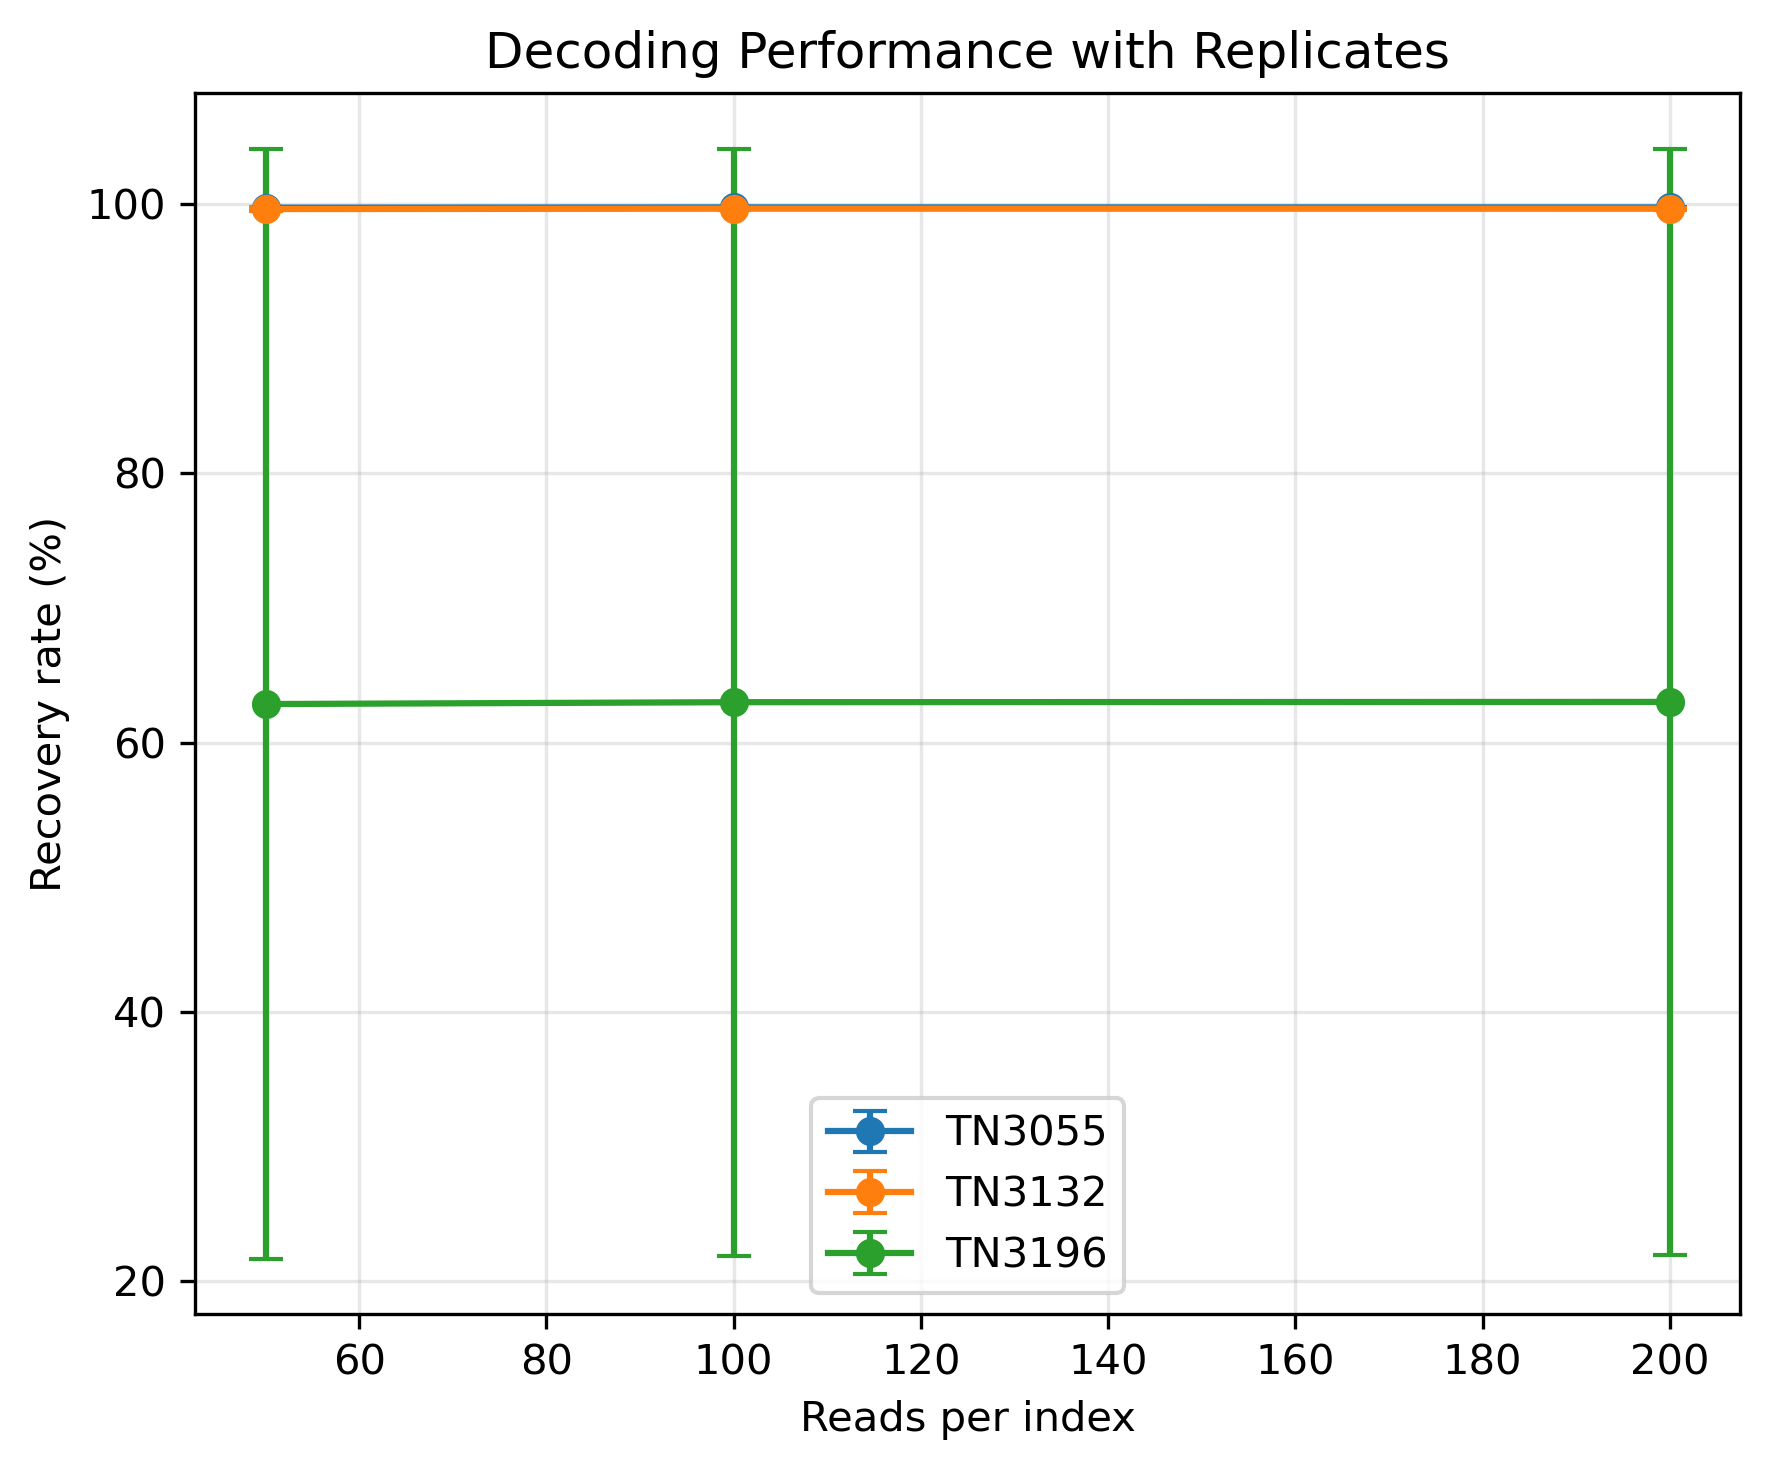

In [5]:
plt.figure(figsize=(6,5), dpi=300)

for group in grouped_df['group'].unique():
    sub = grouped_df[grouped_df['group'] == group].sort_values('reads')

    plt.errorbar(
        sub['reads'],
        sub['mean_recovery'],
        yerr=sub['std_recovery'],
        marker='o',
        capsize=4,
        label=group
    )

plt.xlabel("Reads per index")
plt.ylabel("Recovery rate (%)")
plt.title("Decoding Performance with Replicates")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

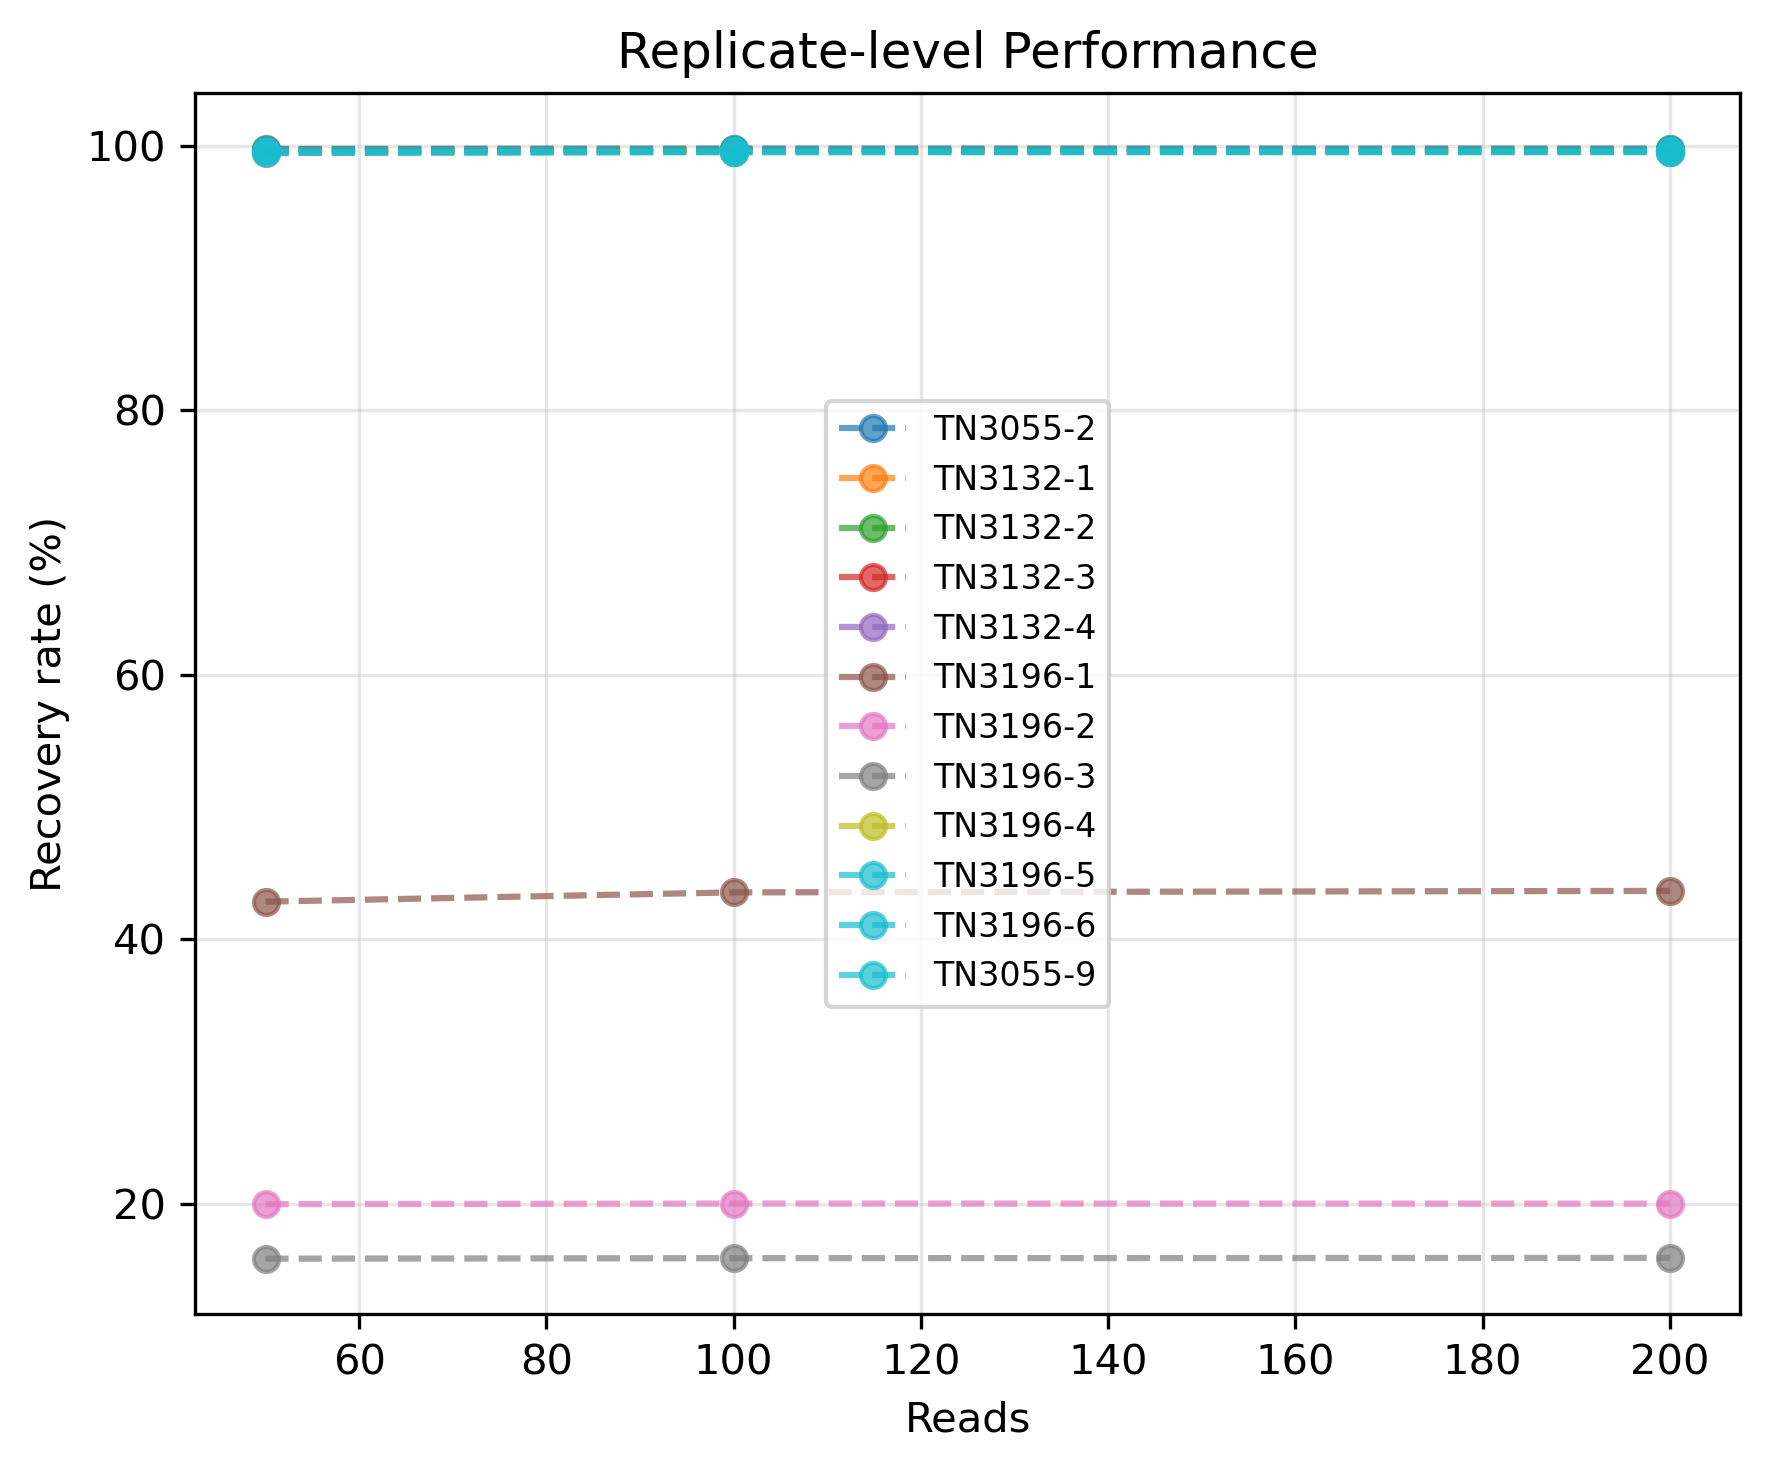

In [14]:
plt.figure(figsize=(6,5), dpi=300)

# 使用颜色映射来为每个图例分配不同的颜色
colors = plt.cm.tab10(range(len(summary_df['replicate'].unique())))

for idx, rep in enumerate(summary_df['replicate'].unique()):
    sub = summary_df[summary_df['replicate'] == rep].sort_values('reads')

    plt.plot(
        sub['reads'],
        sub['recovery_rate'],
        '--o',
        alpha=0.7,
        label=rep,
        color=colors[idx]  # 为每个图例分配不同的颜色
    )

plt.xlabel("Reads")
plt.ylabel("Recovery rate (%)")
plt.title("Replicate-level Performance")

plt.legend(fontsize=8)   # 显示图例
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

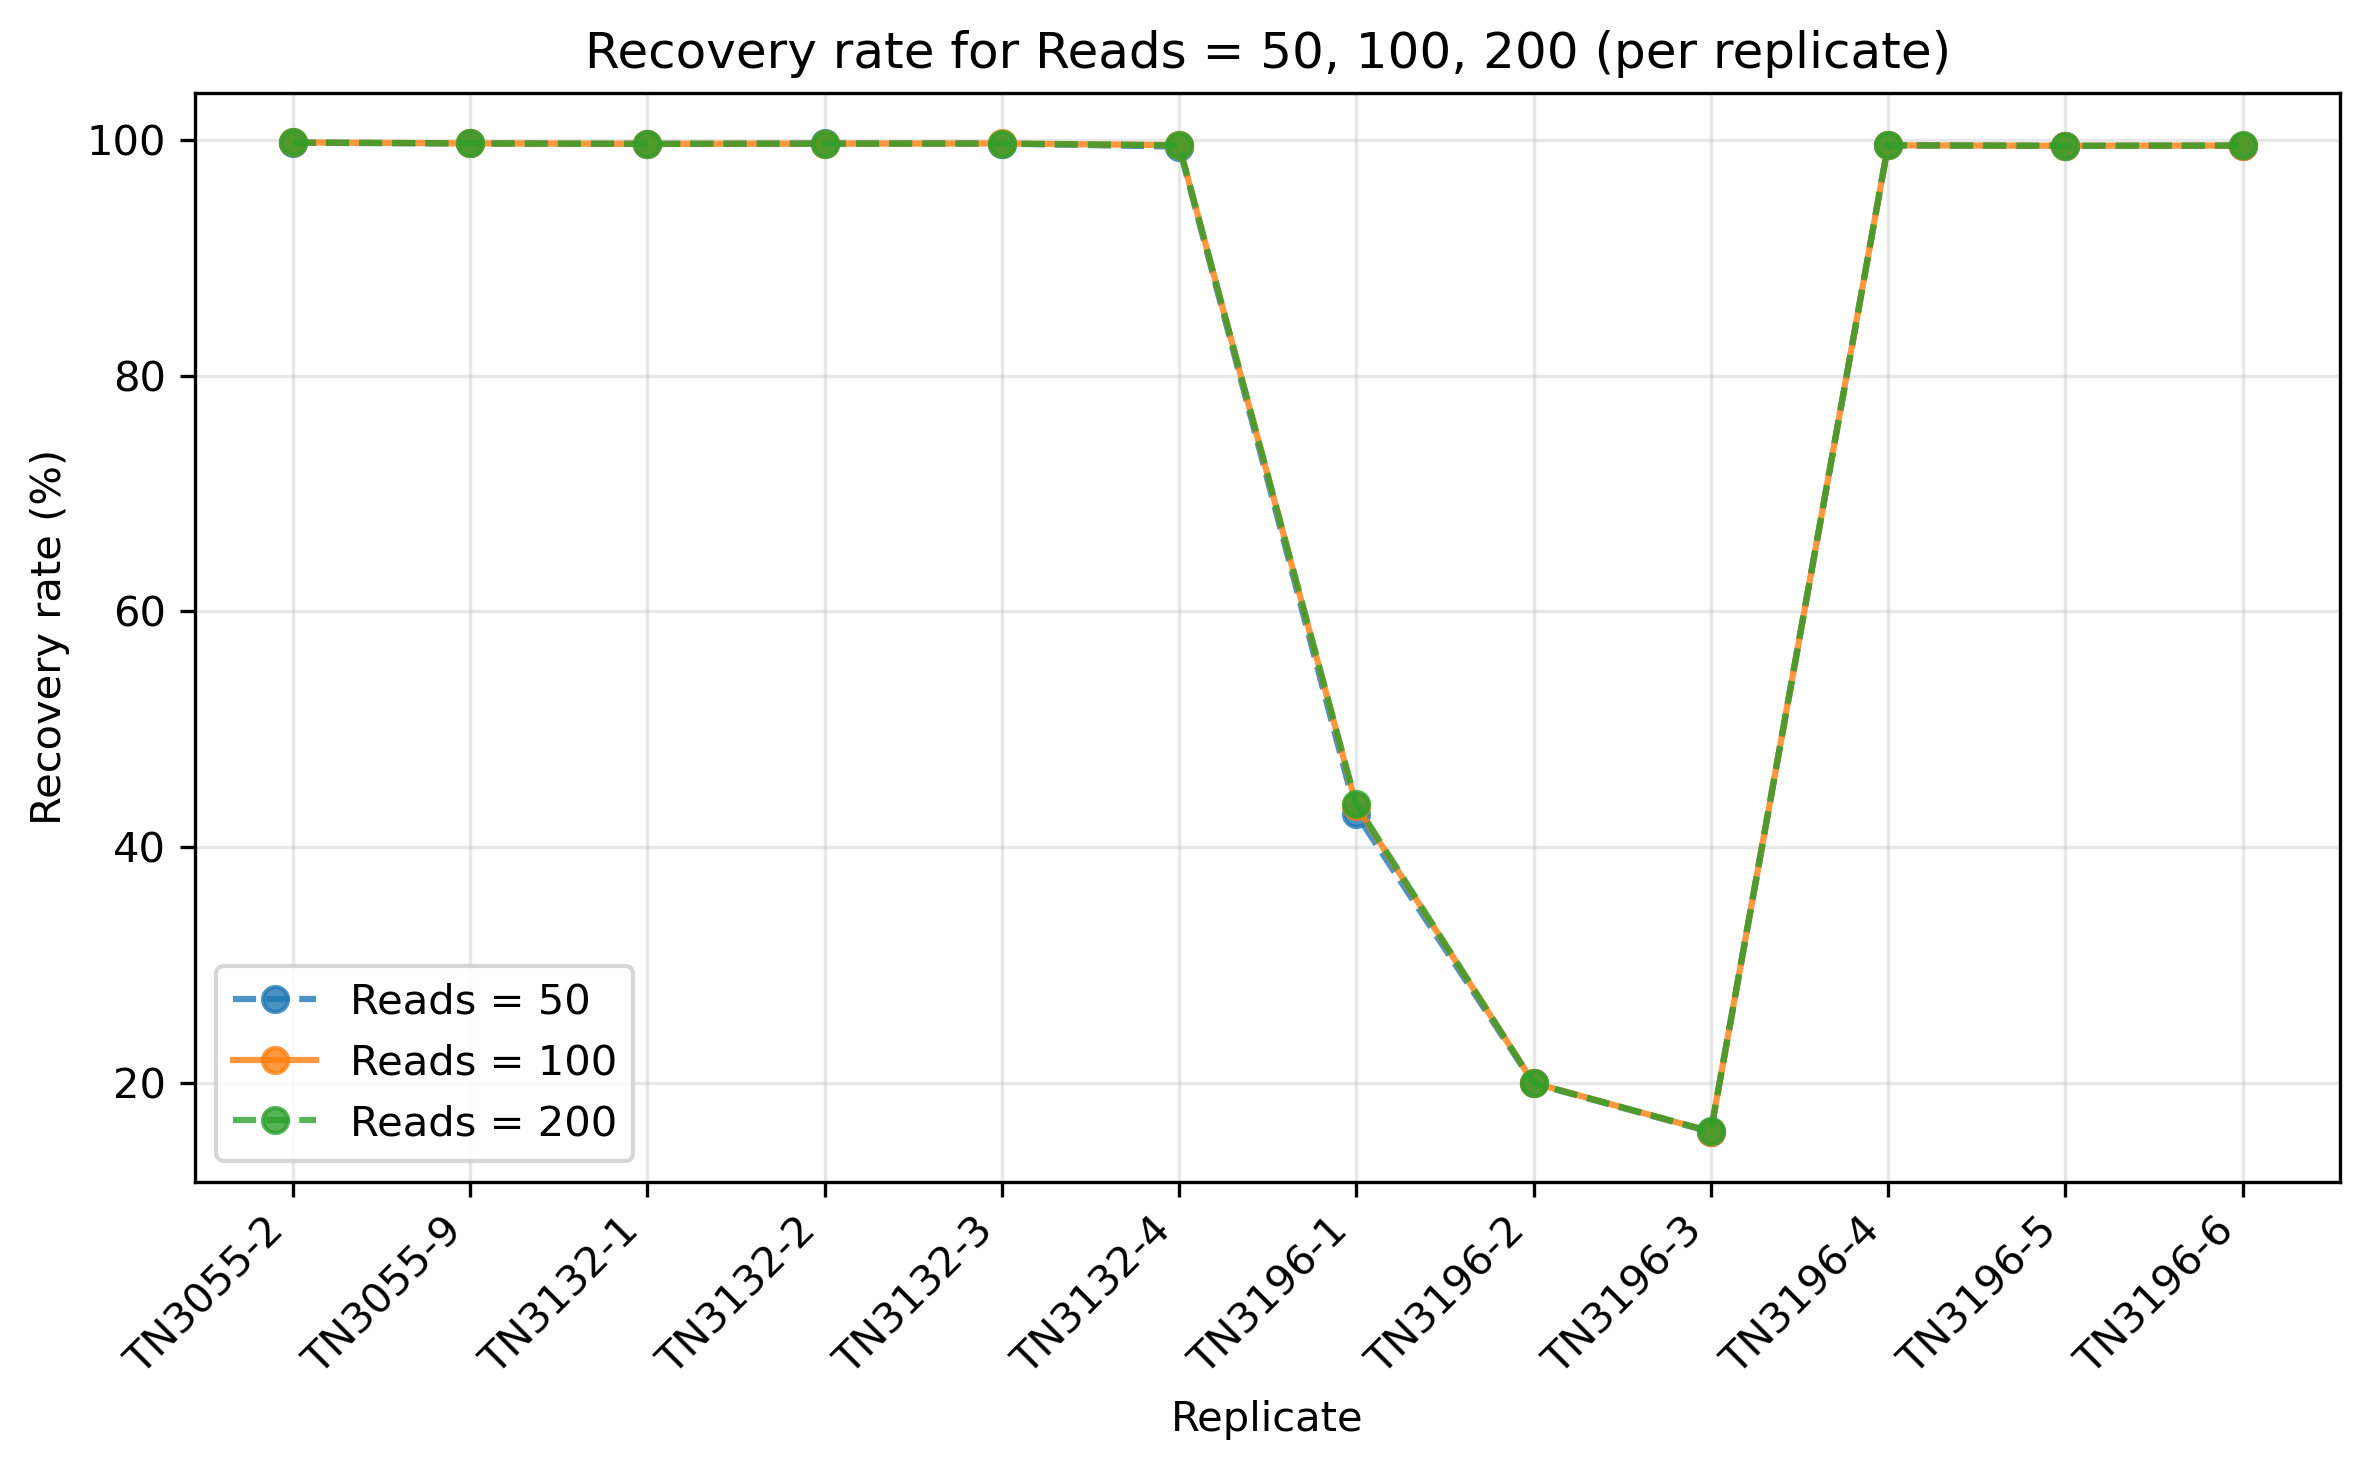

In [15]:
# 将 50/100/200 三组绘在同一张图（共享 x 轴为 replicate）
reads_list = [50, 100, 200]

# 构建透视表，索引为 replicate，列为 reads，值为 recovery_rate
pivot = summary_df.pivot(index='replicate', columns='reads', values='recovery_rate')

x = range(len(pivot))

plt.figure(figsize=(8,5), dpi=300)

# 使用已有的 colors 数组为三条线指定颜色
for i, r in enumerate(reads_list):
    if r not in pivot.columns:
        continue
    y = pivot[r]
    plt.plot(
        x,
        y,
        marker='o',
        linestyle='-' if r == 100 else '--',
        alpha=0.8,
        label=f"Reads = {r}",
        color=colors[i]
    )

plt.xticks(x, pivot.index, rotation=45, ha='right')
plt.xlabel("Replicate")
plt.ylabel("Recovery rate (%)")
plt.title("Recovery rate for Reads = 50, 100, 200 (per replicate)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()